In [2]:
import sys
import uproot
import ROOT as r
import numpy as np
import array as arr
import awkward as ak
import os
import matplotlib.pyplot as plt
sys.path.append("/exp/icarus/app/users/micarrig/nuESpine/")
from utilities_custom import *

Welcome to JupyROOT 6.30/02


In [10]:
fall = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine16/merged_output.root:events/NuMIFull/all")
#fall = uproot.open("/nashome/m/micarrig/icarus/nuESpine/gundam_nueCCInclusive.root:events/NuMIFull/selected")
#fall = uproot.open("/exp/icarus/app/users/micarrig/nuESpine/output_nueCCInclusive.root:events/NuMIFull/selected")

fevt = uproot.open("root://fndcadoor.fnal.gov:/icarus/scratch/users/micarrig/nueCCInclusiveSpine16/merged_output.root:events/NuMIFull/eventLevel")

In [11]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
selections.append(selection("reco_flash_cut", "Flash Cut"))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
selections.append(selection("reco_vertex_distance_cut", "Vertex Distance < 3.25 cm"))
selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>=', threshold=0.72))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>=', threshold=0.97))
selections.append(selection("reco_leading_electron_energy", "Leading Electron Energy > 225 MeV", operator='>', threshold=225))

In [12]:
plotVar = "reco_leading_electron_energy"
var = fall[plotVar].array()
truth_type = fall['true_category'].array()

sel_mask = ak.ones_like(var, dtype=bool)
for sel in selections:
    print(f"Processing selection: {sel.name}")
    sel_mask = sel_mask & sel.apply_cut(fall[sel.name].array())

sel_var = var[sel_mask]
sel_truth_type = truth_type[sel_mask]

print("Total events: ", len(var))
print("Selected events: ", len(ak.drop_none(ak.nan_to_none(truth_type))))

Processing selection: reco_no_cut
Processing selection: reco_fiducial_cut
Processing selection: reco_flash_cut
Processing selection: reco_containment_cut
Processing selection: reco_vertex_distance_cut
Processing selection: reco_has_particle_multiplicity
Processing selection: reco_no_muons
Processing selection: reco_leading_electron_electron_softmax
Processing selection: reco_leading_electron_primary_softmax
Processing selection: reco_leading_electron_energy
Total events:  11306582
Selected events:  11046192


Type 6 (Other): 0 events
Type 5 (Cosmic): 18 events
Type 4 (NC): 192 events
Type 3 (Nu CC OOFV): 35 events
Type 2 (NuMuCC): 65 events
Type 1 (NuE OOFV): 59 events
Type 0 (Signal): 1926 events


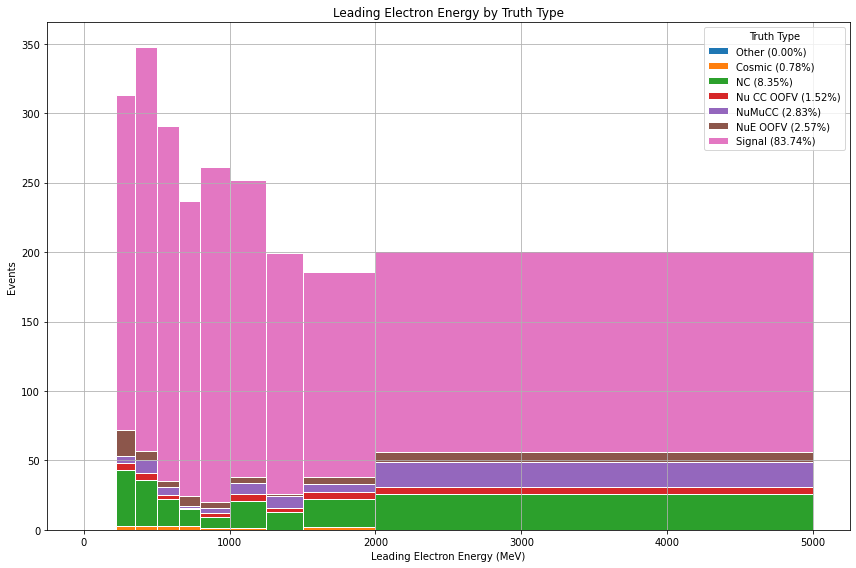

In [13]:
types = {'Signal' : 0, 'NuE OOFV' : 1, 'NuMuCC' : 2, 'Nu CC OOFV' : 3, 'NC' : 4, 'Cosmic' : 5, 'Other' : 6}
bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

plt.figure(figsize=(12,8))

for i, (name, val) in enumerate(list(types.items())[::-1]):
    count = np.sum(sel_truth_type == val)
    print(f"Type {val} ({name}): {count} events")
    mask = sel_truth_type == val
    frac = count / len(sel_truth_type) if len(sel_truth_type) > 0 else 0
    # accumulate per-type arrays and draw once at the last iteration to produce a stacked histogram
    if i == 0:
        _stacked_data = []
        _stacked_labels = []
        _stacked_colors = []

    _stacked_data.append(sel_var[mask])
    _stacked_labels.append(f'{name} ({frac*100:.2f}%)')
    _stacked_colors.append(f'C{i}')

    if i == len(types) - 1:
        plt.hist(_stacked_data, bins=bins, stacked=True, label=_stacked_labels, color=_stacked_colors, edgecolor='white')

plt.xlabel('Leading Electron Energy (MeV)')
plt.ylabel('Events')
plt.title('Leading Electron Energy by Truth Type')
plt.legend(title='Truth Type')
plt.grid(True)
plt.tight_layout()

In [100]:
sb_selections = []
sb_selections.append(selection("reco_no_cut", "No Cut"))
sb_selections.append(selection("reco_fiducial_cut", "Fiducial Cut"))
sb_selections.append(selection("reco_flash_cut", "Flash Cut"))
sb_selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
sb_selections.append(selection("reco_leading_electron_vertex_distance", "Vertex Distance > 6 cm", operator=">", threshold=6))
sb_selections.append(selection("reco_has_particle_multiplicity", ">=1 Electron-like Particle"))
sb_selections.append(selection("reco_leading_electron_energy", "Leading Electron Energy >= 225 MeV", operator='>=', threshold=225))
# sb_selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
#sb_selections.append(selection("reco_no_charged_pions", "0 Pion-like Particles", operator='==', threshold=1))
#sb_selections.append(selection("reco_has_photons", ">=2 Photon-like Particles", operator='==', threshold=1))
# sb_selections.append(selection("reco_photon_multiplicity", ">= 2 Photon-like Particles", operator='>=', threshold=2))
#sb_selections.append(selection("reco_photon_multiplicity", "<= 3 Photon-like Particles", operator='<=', threshold=3))
#sb_selections.append(selection("reco_leading_photon_energy", "Leading Photon Energy > 40 MeV", operator='>', threshold=20))
#sb_selections.append(selection("reco_secondary_photon_energy", "Secondary Photon Energy > 25 MeV", operator='>', threshold=15))
# sb_selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>', threshold=0.72))
# sb_selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.97", operator='>', threshold=0.97))
# sb_selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.72", operator='>=', threshold=0.72))
# sb_selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.95", operator='<', threshold=0.95))


In [104]:
plotVars = ["reco_leading_electron_energy", 
            "reco_leading_photon_energy", 
            "reco_secondary_photon_energy", 
            "reco_leading_electron_electron_softmax", 
            "reco_leading_electron_primary_softmax", 
            "reco_leading_photon_photon_softmax", 
            "reco_leading_photon_primary_softmax",
            "reco_leading_photon_axial_spread",
            "reco_leading_photon_directional_spread",
            "reco_leading_electron_vertex_distance",
            "reco_leading_electron_axial_spread",
            "reco_leading_electron_directional_spread",]
            
vars_ = [fall[plotVar].array() for plotVar in plotVars]
truth_type = fall['true_category'].array()

sel_mask = ak.ones_like(vars_[0], dtype=bool)
for sel in sb_selections:
    print(f"Processing selection: {sel.name}")
    sel_mask = sel_mask & sel.apply_cut(fall[sel.name].array())

sel_vars = [var[sel_mask] for var in vars_]
sel_truth_type = truth_type[sel_mask]

sel_vars[0] = ak.nan_to_num(sel_vars[0], nan=-1)  # replace NaNs in leading electron energy with -1 for plotting
sel_vars[1] = ak.nan_to_num(sel_vars[1], nan=-1)  # replace NaNs in leading photon energy with -1 for plotting
sel_vars[2] = ak.nan_to_num(sel_vars[2], nan=-1)  # replace NaNs in secondary photon energy with -1 for plotting

Processing selection: reco_no_cut
Processing selection: reco_fiducial_cut
Processing selection: reco_flash_cut
Processing selection: reco_containment_cut
Processing selection: reco_leading_electron_vertex_distance
Processing selection: reco_has_particle_multiplicity
Processing selection: reco_leading_electron_energy


In [105]:
bins = [
    [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000], 
    np.arange(0, 2000, 20),
    np.arange(0, 2000, 20),
    np.arange(0, 1, 0.02),
    np.arange(0, 1, 0.02),
    np.arange(0, 1, 0.02),
    np.arange(0, 1, 0.02),
    np.arange(-1, 1, 0.05),
    np.arange(-1, 1, 0.05),
    np.arange(0, 10, 0.5),
    np.arange(-1, 1, 0.05),
    np.arange(-1, 1, 0.05),
]

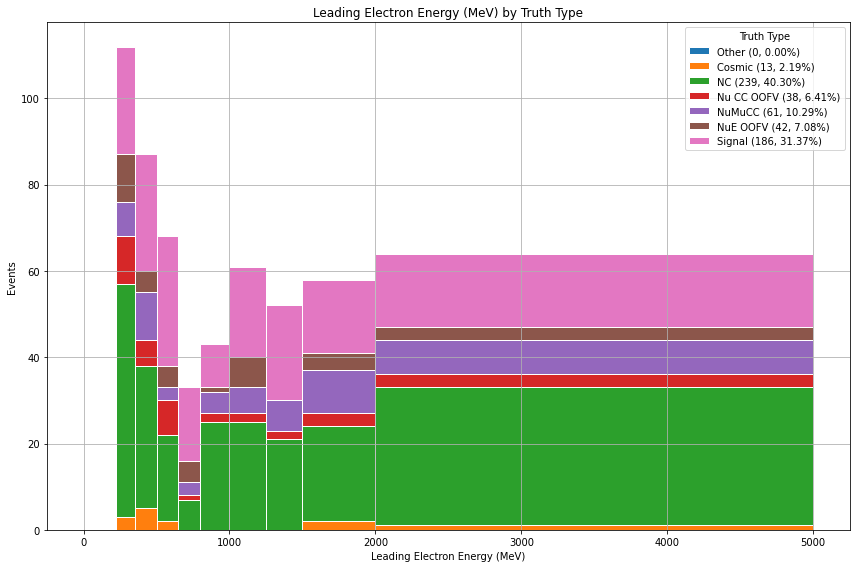

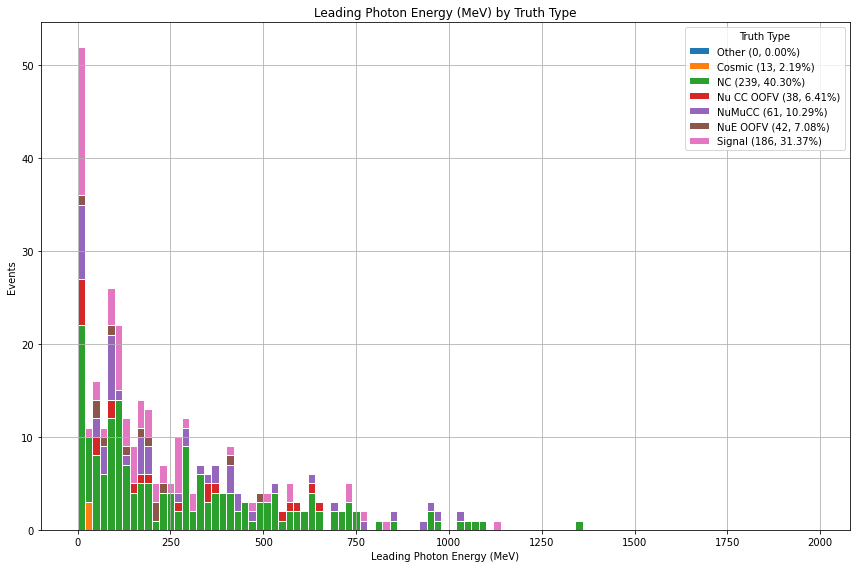

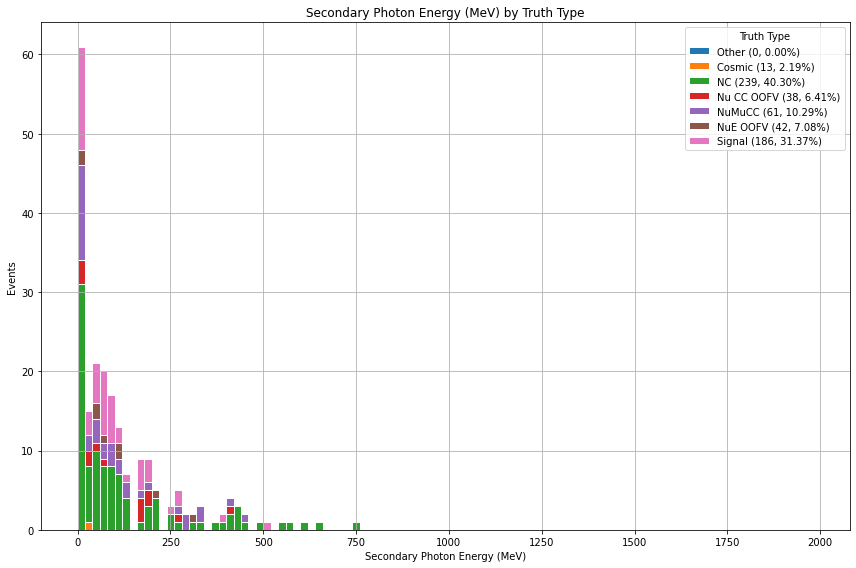

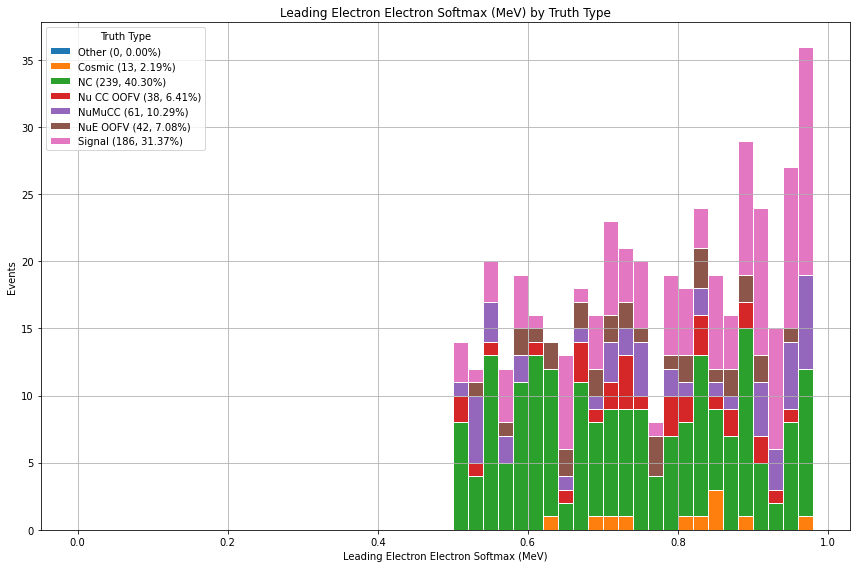

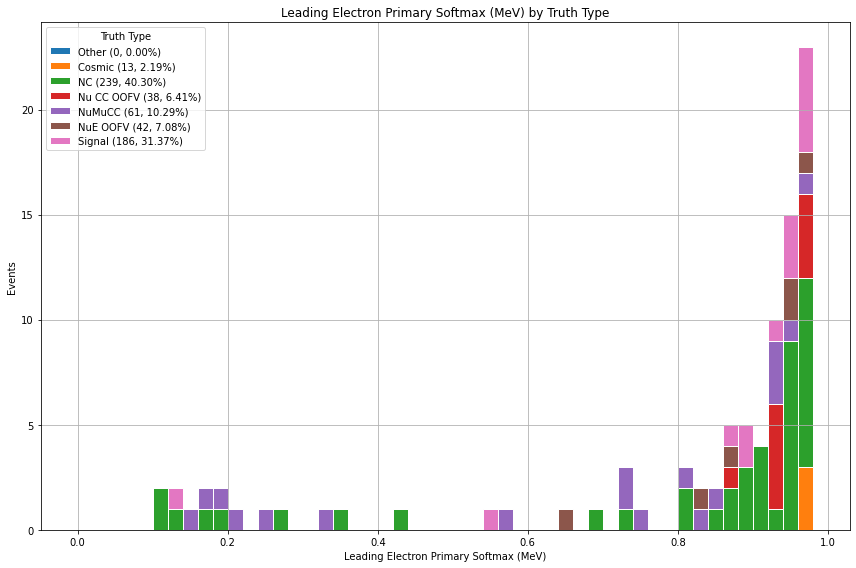

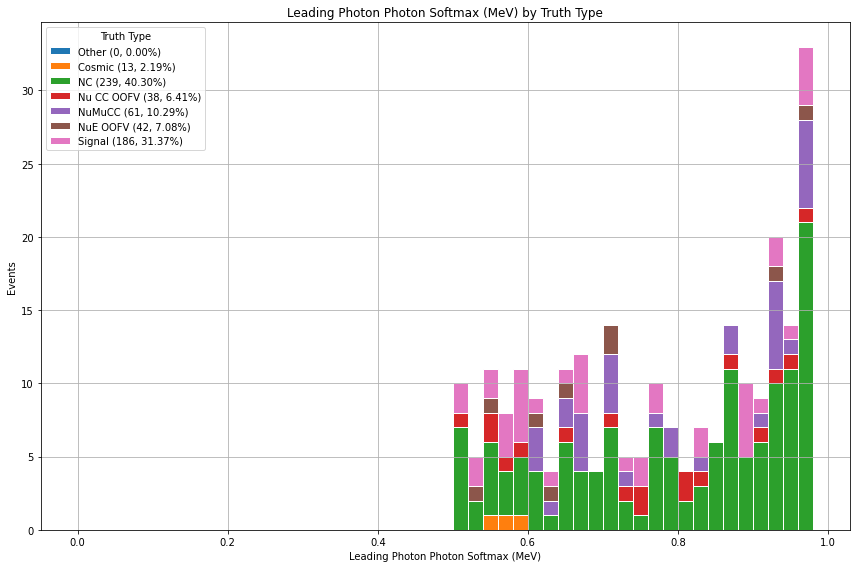

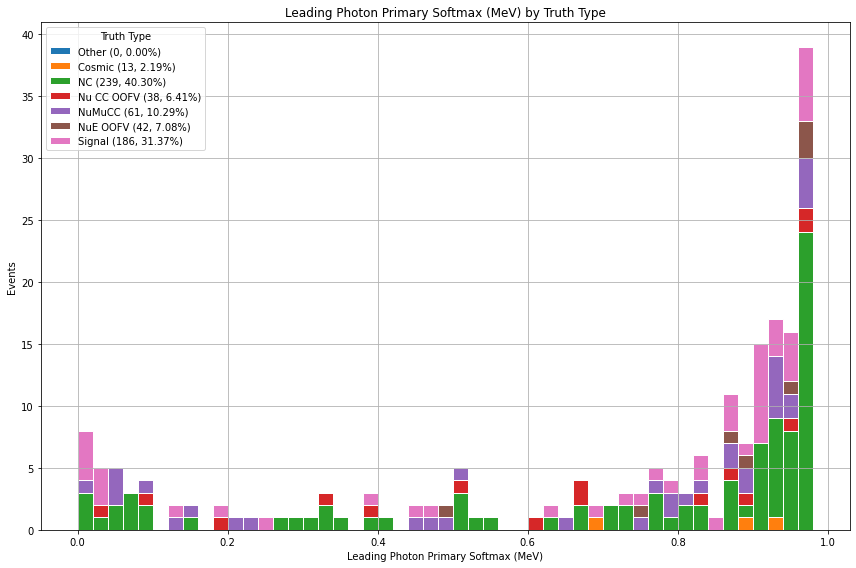

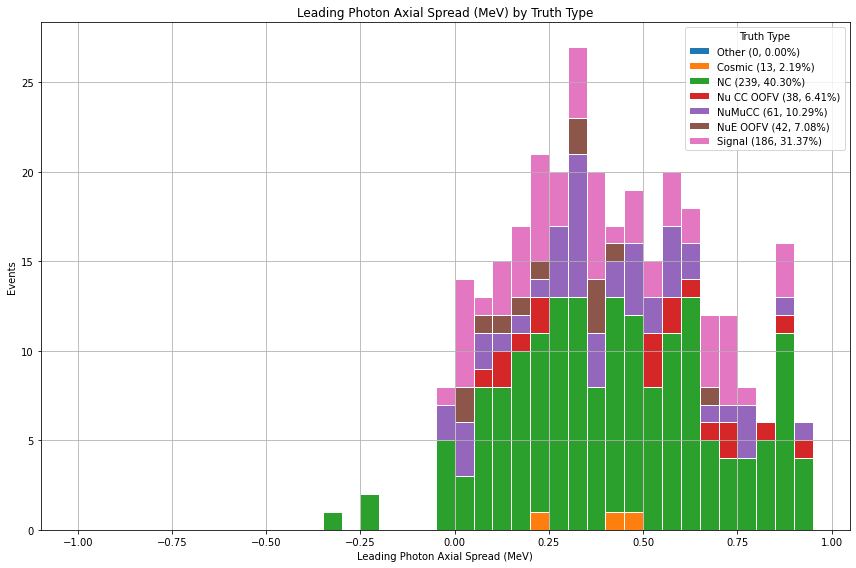

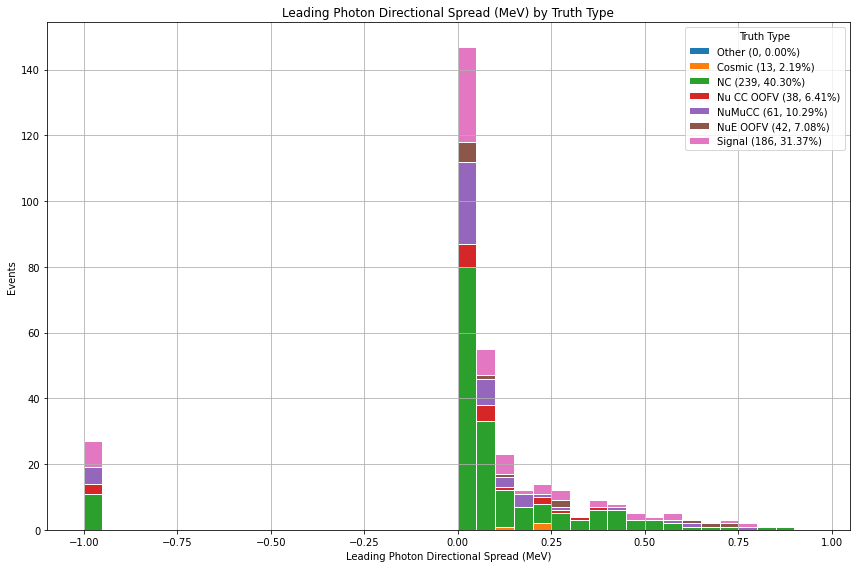

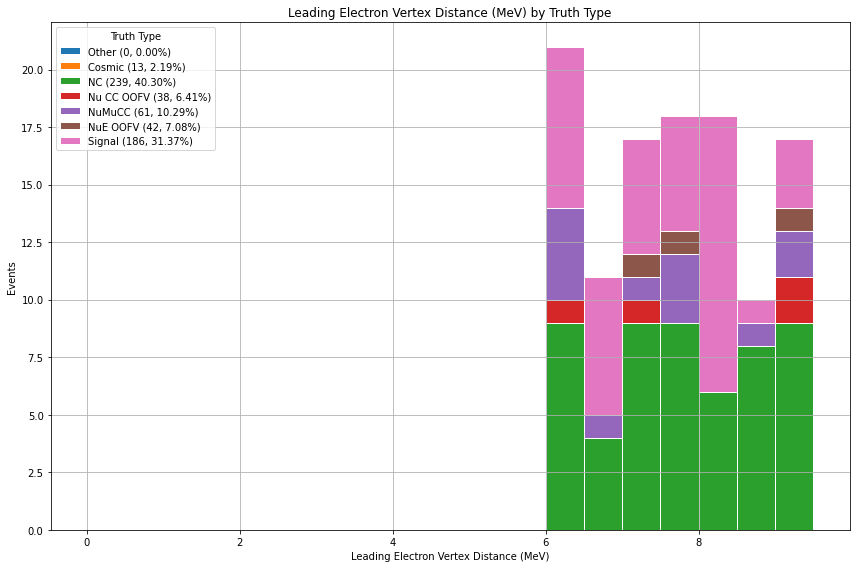

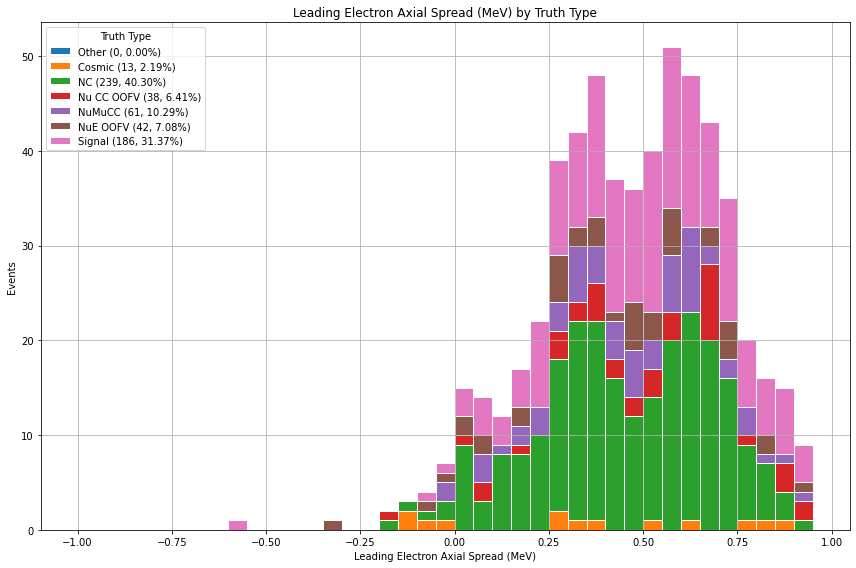

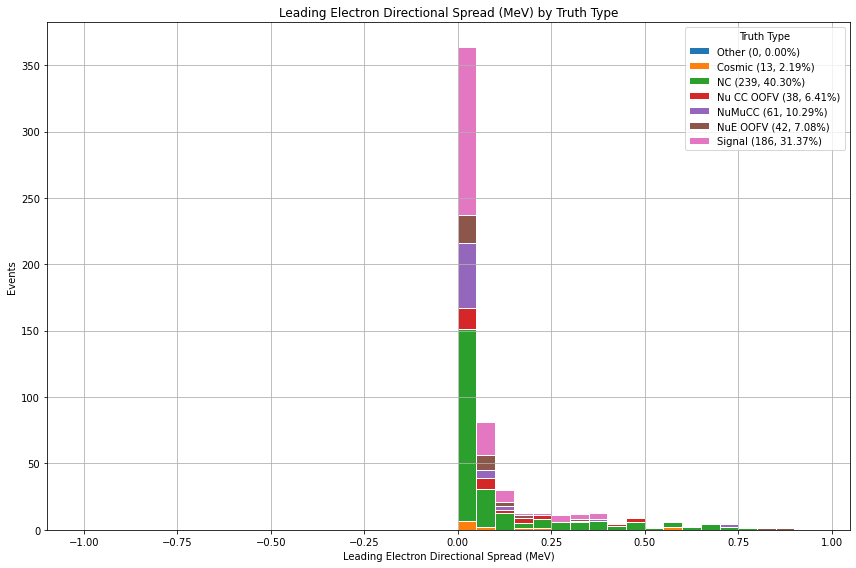

In [106]:
# Plot each variable in sel_vars separately (uses existing plotVars for labels)
for ivar, var in enumerate(sel_vars):
    plt.figure(figsize=(12,8))

    _stacked_data = []
    _stacked_labels = []
    _stacked_colors = []

    for i, (name, val) in enumerate(list(types.items())[::-1]):
        mask = sel_truth_type == val
        count = np.sum(mask)
        frac = count / len(sel_truth_type) if len(sel_truth_type) > 0 else 0

        _stacked_data.append(var[mask])
        _stacked_labels.append(f'{name} ({count}, {frac*100:.2f}%)')
        _stacked_colors.append(f'C{i}')

    plt.hist(_stacked_data, bins=bins[ivar], stacked=True, label=_stacked_labels, color=_stacked_colors, edgecolor='white')

    # Use plotVars for a nicer xlabel if available
    xlabel = plotVars[ivar] if ivar < len(plotVars) else f'Var {ivar}'
    xlabel = xlabel.replace('reco_', '').replace('_', ' ').title() + ' (MeV)'
    plt.xlabel(xlabel)
    plt.ylabel('Events')
    plt.title(f'{xlabel} by Truth Type')
    plt.legend(title='Truth Type')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [107]:
#2d plot of leading electron axial spread vs directional spread

signal_axial = sel_vars[7][sel_truth_type == types['Signal']]
signal_directional = sel_vars[8][sel_truth_type == types['Signal']]

nc_axial = sel_vars[7][sel_truth_type == types['NC']]
nc_directional = sel_vars[8][sel_truth_type == types['NC']]


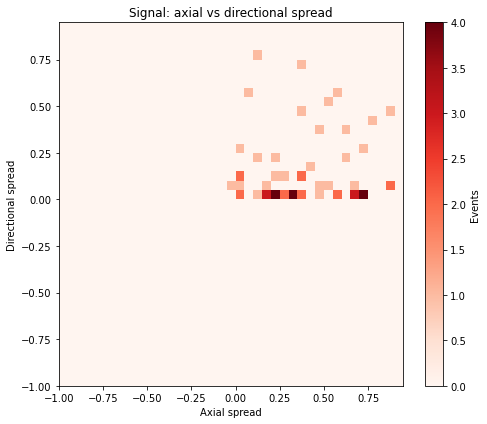

In [114]:
x = ak.to_numpy(signal_axial)
y = ak.to_numpy(signal_directional)

valid = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(7, 6))
h = plt.hist2d(
    x[valid],
    y[valid],
    bins=[bins[7], bins[8]],   # uses your existing binning for spreads
    range=[[-1, 1], [-1, 1]],
    cmap="Reds"
)

plt.colorbar(h[3], label="Events")
plt.xlabel("Axial spread")
plt.ylabel("Directional spread")
plt.title("Signal: axial vs directional spread")
plt.tight_layout()
plt.show()

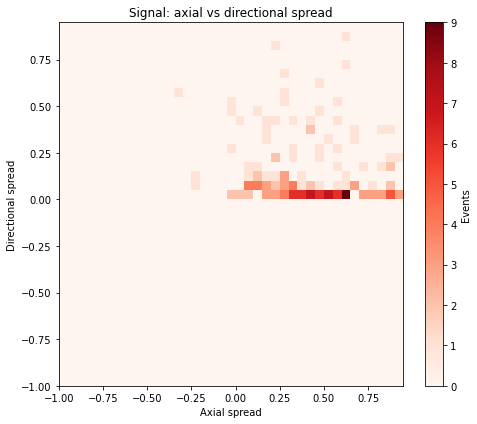

In [115]:
x = ak.to_numpy(nc_axial)
y = ak.to_numpy(nc_directional)

valid = np.isfinite(x) & np.isfinite(y)

plt.figure(figsize=(7, 6))
h = plt.hist2d(
    x[valid],
    y[valid],
    bins=[bins[7], bins[8]],   # uses your existing binning for spreads
    range=[[-1, 1], [-1, 1]],
    cmap="Reds"
)

plt.colorbar(h[3], label="Events")
plt.xlabel("Axial spread")
plt.ylabel("Directional spread")
plt.title("Signal: axial vs directional spread")
plt.tight_layout()
plt.show()

In [30]:
nEvt = ak.sum(fevt['event_nnu_e'].array())
print("Total nue events:", nEvt)
hists_spine = get_effHists('reco_leading_electron_energy', fall, sb_selections, total=nEvt, bins=bins[0], xmin=0, xmax=5000, signal_index=4) #signal is NC

Total nue events: 14938.0
Applying selection: No Cut
total entries in selection: 11306582
Selected entries: 11046192
Purity: 63823/11046192 = 0.0058
Efficiency after No Cut: 1.0000 (63823/63823)
Applying selection: Fiducial Cut
total entries in selection: 4130763
Selected entries: 4023929
Purity: 39158/4023929 = 0.0097
Efficiency after Fiducial Cut: 0.6135 (39158/63823)
Applying selection: Flash Cut
total entries in selection: 123209
Selected entries: 120865
Purity: 25121/120865 = 0.2078
Efficiency after Flash Cut: 0.3936 (25121/63823)
Applying selection: Interaction Containment Cut
total entries in selection: 59861
Selected entries: 57539
Purity: 23090/57539 = 0.4013
Efficiency after Interaction Containment Cut: 0.3618 (23090/63823)
Applying selection: Vertex Distance >= 3.25 cm
total entries in selection: 2717
Selected entries: 2512
Purity: 1108/2512 = 0.4411
Efficiency after Vertex Distance >= 3.25 cm: 0.0174 (1108/63823)
Applying selection: >=1 Electron-like Particle
total entries 

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [34]:
print_selection_stats(sb_selections)


Selection Summary
Selection                           Slice/Int Efficiency  Neutrino Efficiency       Purity
----------------------------------------------------------------------------------------------------
No Cut                              1.0000 (63823/63823) 4.2725 (63823/14938.0) 0.0058 (63823/11046192)
Fiducial Cut                        0.6135 (39158/63823) 2.6214 (39158/14938.0) 0.0097 (39158/4023929)
Flash Cut                           0.3936 (25121/63823) 1.6817 (25121/14938.0) 0.2078 (25121/120865)
Interaction Containment Cut         0.3618 (23090/63823) 1.5457 (23090/14938.0) 0.4013 (23090/57539)
>=1 Electron-like Particle          0.3618 (23090/63823) 1.5457 (23090/14938.0) 0.4013 (23090/57539)
Leading Electron Energy > 225 MeV     0.0096 (611/63823) 0.0409 (611/14938.0) 0.1756 (611/3479)
>= 2 Photon-like Particles            0.0025 (161/63823) 0.0108 (161/14938.0) 0.2795 (161/576)
Leading Electron Softmax < 0.72        0.0009 (59/63823)  0.0039 (59/14938.0) 0.4370 (5